In [1]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cmocean

In [2]:
def setup_axes(ax, res='110m'):
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
    ax.coastlines(resolution=res, color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')


def label_ax(ax, label, position='top', fontsize=16):
    if position == 'inside':
        ax.annotate(
            label,
            xy=(0, 1), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize=fontsize, verticalalignment='top', fontfamily='serif',
            bbox=dict(facecolor='1.', edgecolor='k', pad=3.0))
    elif position == 'top':
        ax.text(
            0.0, 1.0, label, transform=(
                ax.transAxes + ScaledTranslation(7/72, +3/72, fig.dpi_scale_trans)),
            fontsize=fontsize, va='bottom', fontfamily='sans-serif')

In [3]:
data_fold = '../final_data'
ds = xr.open_dataset(f'{data_fold}/example_fields.nc')

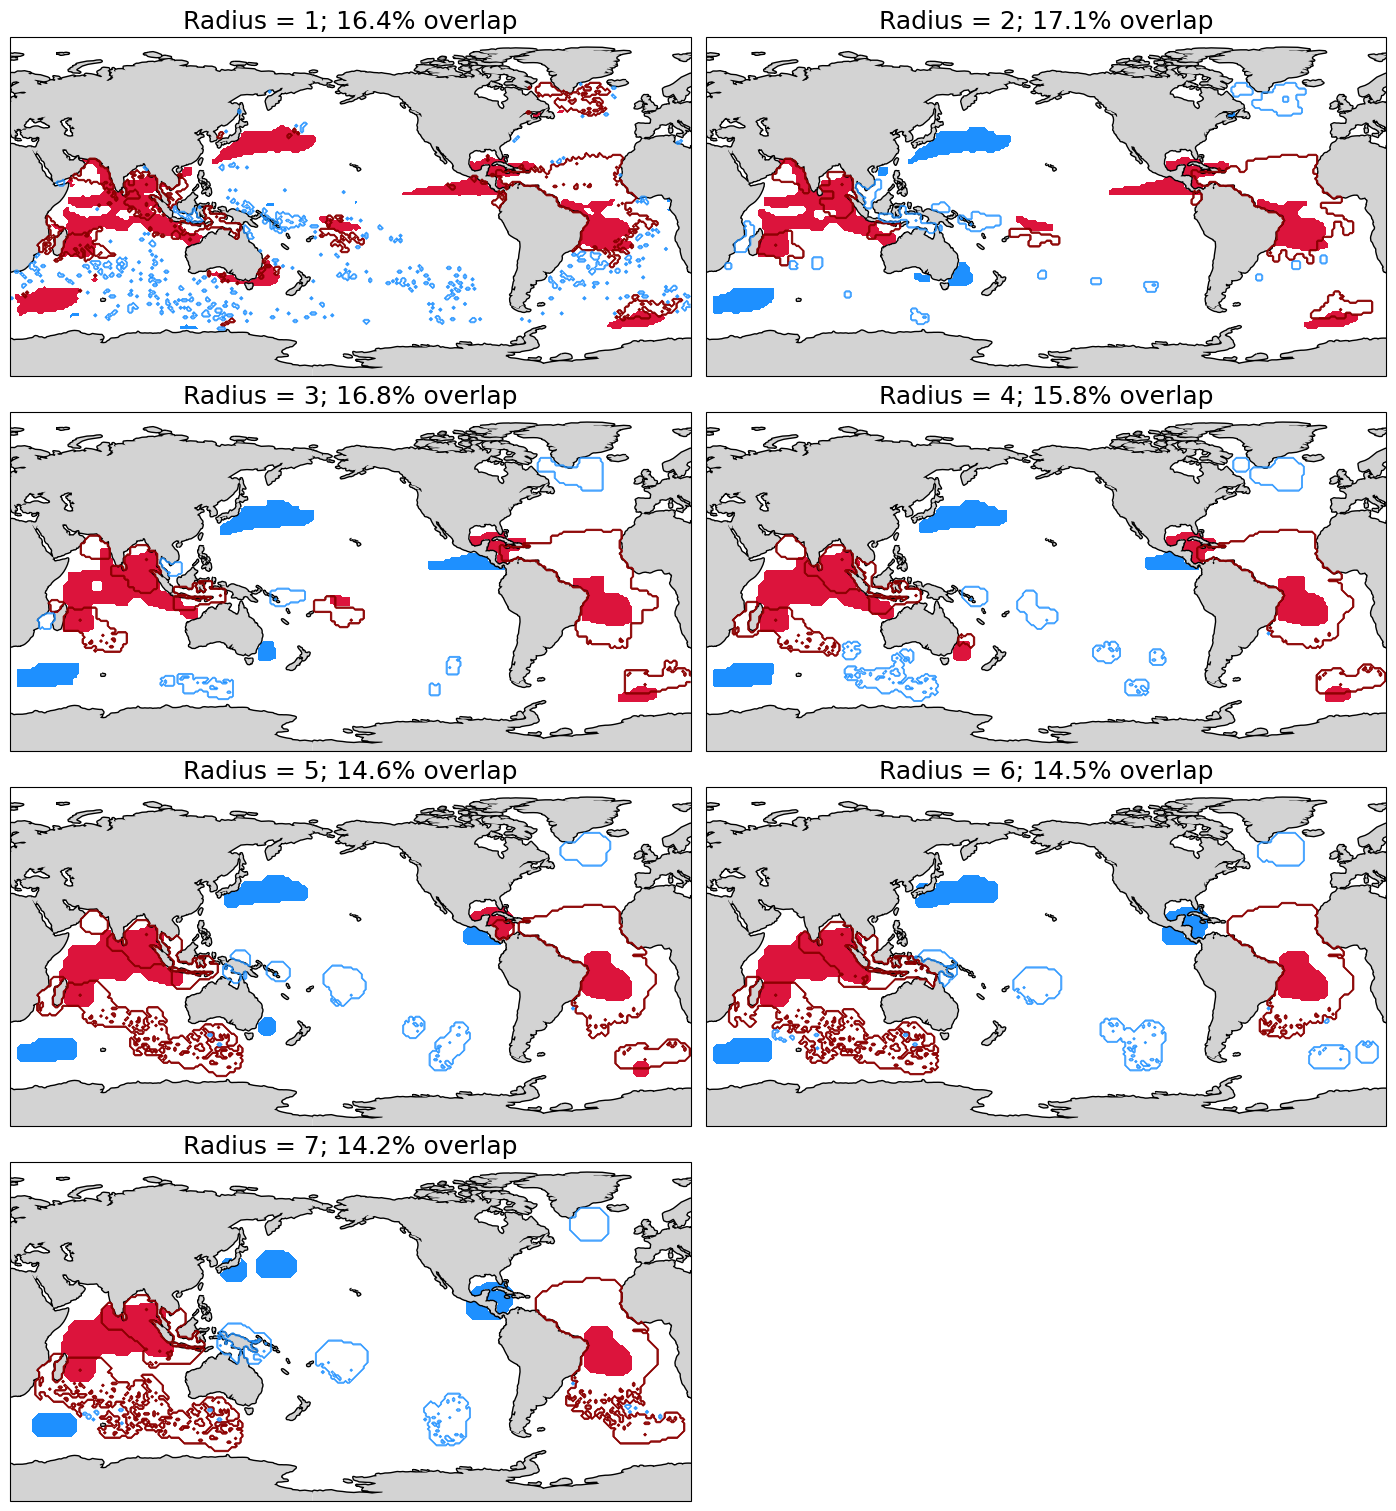

In [6]:
rs = [1, 2, 3, 4, 5, 6, 7]
fig, axs = plt.subplots(4, 2, figsize=(15, 15), subplot_kw={'projection': ccrs.PlateCarree(200)}, layout='compressed')

for i in range(7):
    r = rs[i]
    ax = axs.flatten()[i]
    ds_ex = ds.sel(radius=r)
    setup_axes(ax)
    data0 = xr.where(ds_ex['fcst_clus_id']>0, ds_ex['fcst_clus_id'], np.nan) # Matched forecast cluster (hit)
    data1 = xr.where(ds_ex['fcst_clus_id']<0, True, np.nan) # Unmatched forecast cluster (false alarm)
    data2 = xr.where(ds_ex['obs_clus_id']>0, True, False) # Matched observed cluster
    data3 = xr.where(ds_ex['obs_clus_id']<0, True, False) # Unmatched observed cluster (miss)

    union = xr.where((~np.isnan(ds_ex['fcst_clus_id'])|~np.isnan(ds_ex['obs_clus_id'])), 1, 0).sum(['lat', 'lon'])
    intersection = xr.where((~np.isnan(ds_ex['fcst_clus_id'])&~np.isnan(ds_ex['obs_clus_id'])), 1, 0).sum(['lat', 'lon'])
    fiou = intersection / union

    CMap = ListedColormap(['crimson'])
    CMapbad = ListedColormap(['dodgerblue'], N=10)

    im0 = ax.contourf(data0.lon, data0.lat, data0, transform=ccrs.PlateCarree(), cmap=CMap)
    im1 = ax.contourf(data1.lon, data1.lat, data1, transform=ccrs.PlateCarree(), cmap=CMapbad, vmin=0, vmax=1.3)
    im2 = ax.contour(data2.lon, data2.lat, data2, 3, transform=ccrs.PlateCarree(), colors='darkred', linewidths=0.6)
    im3 = ax.contour(data3.lon, data3.lat, data3, 3, transform=ccrs.PlateCarree(), colors='dodgerblue', linewidths=0.4)
    ax.set_title(f'Radius = {r}; {fiou.values*100:.01f}% overlap', fontsize=18)

axs.flatten()[-1].remove()
plt.savefig('../final_figs/figS5.pdf')
plt.show()